In [1]:
from OpenElectricity_data_manager import OpenElectricityDataManager
import pandas as pd

In [10]:
manager = OpenElectricityDataManager(
    network_code='NEM',
    start_time='2026-06-20 00:00:00',
    end_time='2026-06-27 00:00:00',
    interval='1h',
    network_2nd_grp='fueltech'
)

[2026-06-26 16:36:37] DEBUG [openelectricity.client.__init__:150] Initialized client with base URL: https://api.openelectricity.org.au/v4/
[2026-06-26 16:36:37] DEBUG [openelectricity.client.__init__:241] Initialized synchronous client


In [11]:
df_market = manager.fetch_market_data()

Fetching market data for NEM from 2026-06-19 14:00:00 to 2026-06-26 14:00:00
[2026-06-26 16:36:38] DEBUG [openelectricity.client._async_get_market:392] Getting market data for NEM (metrics: [<MarketMetric.PRICE: 'price'>, <MarketMetric.DEMAND: 'demand'>, <MarketMetric.DEMAND_GROSS: 'demand_gross'>, <MarketMetric.FLOW_IMPORTS: 'flow_imports'>, <MarketMetric.FLOW_EXPORTS: 'flow_exports'>], interval: 1h, region: None)
[2026-06-26 16:36:38] DEBUG [openelectricity.client._async_get_market:410] Request parameters: {'metrics': ['price', 'demand', 'demand_gross', 'flow_imports', 'flow_exports'], 'interval': '1h', 'date_start': '2026-06-19T14:00:00', 'date_end': '2026-06-26T14:00:00'}
[2026-06-26 16:36:38] DEBUG [openelectricity.client._handle_response:259] Received successful response: 200
finished fetching market data for NEM from 2026-06-19 14:00:00 to 2026-06-26 14:00:00


In [12]:
df_market

,interval,price,demand,demand_gross,flow_imports,flow_exports
0,2026-06-20 00:00:00,50.706167,22412.370833,28374.728508,1127.509231,1127.509231
1,2026-06-20 01:00:00,55.405667,23726.464167,27391.131050,902.960076,902.960076
2,2026-06-20 02:00:00,72.671333,25669.461667,27446.541742,758.656354,758.656354
3,2026-06-20 03:00:00,75.134167,27551.225833,28249.640792,868.385662,868.385662
4,2026-06-20 04:00:00,70.109500,27568.063333,28151.264900,813.404576,813.404576
...,...,...,...,...,...,...
163,2026-06-26 19:00:00,122.707333,26058.352500,31886.922517,987.746037,987.746037
164,2026-06-26 20:00:00,124.219667,24587.401667,32084.494417,1079.597514,1079.597514
165,2026-06-26 21:00:00,115.914500,23507.472500,32819.543317,998.723184,998.723184
166,2026-06-26 22:00:00,101.567667,22399.035833,32888.799125,1053.894273,1053.894273


In [13]:
df_network = manager.fetch_network_data()

Fetching network data for NEM from 2026-06-19 14:00:00 to 2026-06-26 14:00:00
[2026-06-26 16:36:39] DEBUG [openelectricity.client._async_get_network_data:319] Getting network data for NEM (metrics: [<DataMetric.ENERGY: 'energy'>, <DataMetric.MARKET_VALUE: 'market_value'>, <DataMetric.POWER: 'power'>, <DataMetric.STORAGE_BATTERY: 'storage_battery'>], interval: 1h)
[2026-06-26 16:36:39] DEBUG [openelectricity.client._async_get_network_data:339] Request parameters: {'metrics': ['energy', 'market_value', 'power', 'storage_battery'], 'interval': '1h', 'date_start': '2026-06-19T14:00:00', 'date_end': '2026-06-26T14:00:00', 'secondary_grouping': 'fueltech'}
[2026-06-26 16:36:40] DEBUG [openelectricity.client._handle_response:259] Received successful response: 200
finished fetching network data for NEM from 2026-06-19 14:00:00 to 2026-06-26 14:00:00


In [14]:
df_network

,interval,fueltech,energy,market_value,power,storage_battery
0,2026-06-20 00:00:00,battery,-169.5107,5515.6077,-174.593750,0.0
1,2026-06-20 00:00:00,battery_charging,344.4301,15693.5512,340.248275,0.0
2,2026-06-20 00:00:00,battery_discharging,173.8720,5864.1093,165.654525,0.0
3,2026-06-20 00:00:00,bioenergy_biomass,50.5492,2046.7541,51.012908,0.0
4,2026-06-20 00:00:00,coal_black,7894.1197,333403.3343,7935.330792,0.0
...,...,...,...,...,...,...
2851,2026-06-26 23:00:00,hydro,2097.4605,172910.6985,2093.965825,0.0
2852,2026-06-26 23:00:00,pumps,31.3627,3098.8609,29.531858,0.0
2853,2026-06-26 23:00:00,solar_rooftop,7877.0370,774314.3030,7892.541500,0.0
2854,2026-06-26 23:00:00,solar_utility,4972.5658,468075.5430,4961.555167,0.0


<Axes: >

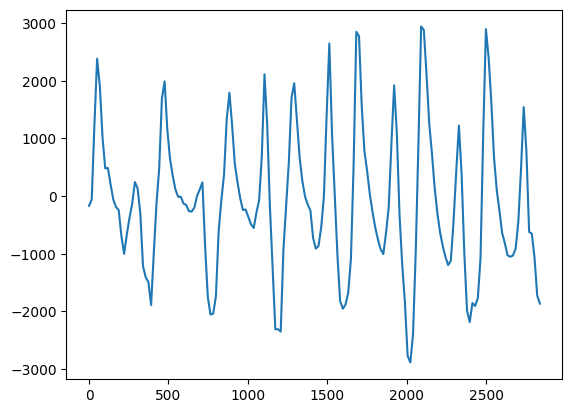

In [16]:
df_network[df_network.fueltech=='battery'].energy.plot()

<Axes: >

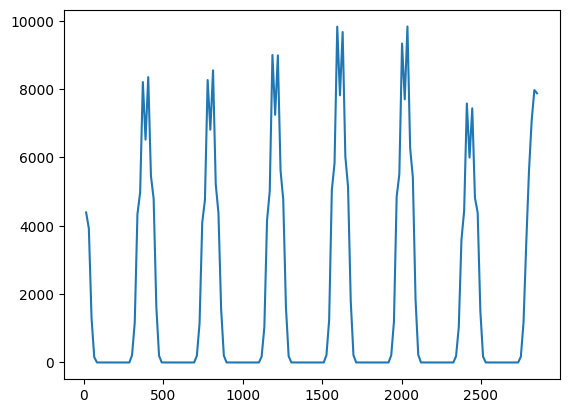

In [17]:
df_network[df_network.fueltech=='solar_rooftop'].energy.plot()

In [32]:
help(client)

Help on OEClient in module openelectricity.client object:

class OEClient(BaseOEClient)
 |  OEClient(api_key: str | None = None, base_url: str | None = None, *, proxy: str | None = None, proxy_auth: aiohttp.helpers.BasicAuth | None = None, verify_ssl: bool = True, ssl_context: ssl.SSLContext | None = None, ca_cert: str | os.PathLike[str] | None = None, trust_env: bool = False) -> None
 |  
 |  Synchronous client for the OpenElectricity API.
 |  
 |  It runs aiohttp under the hood and is safe to call from inside an existing
 |  event loop (e.g. a Jupyter/IPython notebook) — when a loop is already
 |  running, requests are dispatched to a worker thread.
 |  
 |  Method resolution order:
 |      OEClient
 |      BaseOEClient
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __enter__(self) -> 'OEClient'
 |  
 |  __exit__(self, exc_type, exc_val, exc_tb) -> None
 |  
 |  __init__(self, api_key: str | None = None, base_url: str | None = None, *, proxy: str | None = None, proxy

In [33]:
dir(DataMetric)

['EMISSIONS',
 'ENERGY',
 'MARKET_VALUE',
 'POWER',
 'STORAGE_BATTERY',
 '__class__',
 '__doc__',
 '__members__',
 '__module__']

In [29]:
import openelectricity

In [30]:
help(openelectricity)

Help on package openelectricity:

NAME
    openelectricity - OpenElectricity Python SDK

DESCRIPTION
    This package provides a Python client for interacting with the OpenElectricity API.

PACKAGE CONTENTS
    client
    logging
    models (package)
    styles
    types

CLASSES
    openelectricity.client.BaseOEClient(builtins.object)
        openelectricity.client.AsyncOEClient
        openelectricity.client.OEClient
    openelectricity.types.StrEnum(builtins.str, enum.Enum)
        openelectricity.types.DataMetric
        openelectricity.types.FueltechGroupType
        openelectricity.types.MarketMetric
        openelectricity.types.UnitFueltechType
        openelectricity.types.UnitStatusType
    
    class AsyncOEClient(BaseOEClient)
     |  AsyncOEClient(api_key: str | None = None, base_url: str | None = None, *, proxy: str | None = None, proxy_auth: aiohttp.helpers.BasicAuth | None = None, verify_ssl: bool = True, ssl_context: ssl.SSLContext | None = None, ca_cert: str | os.Path

In [34]:
dir(DataMetric)

['EMISSIONS',
 'ENERGY',
 'MARKET_VALUE',
 'POWER',
 'STORAGE_BATTERY',
 '__class__',
 '__doc__',
 '__members__',
 '__module__']

In [35]:
dir(MarketMetric)

['CURTAILMENT',
 'CURTAILMENT_ENERGY',
 'CURTAILMENT_SOLAR_UTILITY',
 'CURTAILMENT_SOLAR_UTILITY_ENERGY',
 'CURTAILMENT_WIND',
 'CURTAILMENT_WIND_ENERGY',
 'DEMAND',
 'DEMAND_ENERGY',
 'DEMAND_GROSS',
 'DEMAND_GROSS_ENERGY',
 'FLOW_EXPORTS',
 'FLOW_EXPORTS_ENERGY',
 'FLOW_IMPORTS',
 'FLOW_IMPORTS_ENERGY',
 'GENERATION_RENEWABLE',
 'GENERATION_RENEWABLE_ENERGY',
 'GENERATION_RENEWABLE_WITH_STORAGE',
 'GENERATION_RENEWABLE_WITH_STORAGE_ENERGY',
 'PRICE',
 'RENEWABLE_PROPORTION',
 'RENEWABLE_WITH_STORAGE_PROPORTION',
 '__class__',
 '__doc__',
 '__members__',
 '__module__']